# 🎥 Video 12: Bemis-Murcko Scaffolds & Molecular Decomposition
**RDKit Masterclass — From Zero to Drug Discovery AI**
* **Duration:** ~25 - 30 Minutes
* **Curriculum Level:** LEVEL 8 — Advanced RDKit (Topics 44, 45, 46)
* **Target Audience:** Medicinal Chemists, Cheminformatics Engineers, AI Researchers

---

### ⏱️ Video Agenda & Timestamps
* **00:00 - 04:30** | Bemis-Murcko Scaffold Theory: Rings, Linkers, and Side Chains
* **04:30 - 09:30** | Extracting Murcko Scaffolds with `MurckoScaffold.GetScaffoldForMol`
* **09:30 - 14:00** | Generic Scaffolds (Carbon Skeletons): `MakeScaffoldGeneric`
* **14:00 - 19:30** | Scaffold Frequency Analysis in the ChEMBL EGFR Dataset
* **19:30 - 24:30** | Scaffold Diversity Metrics & Cumulative Frequency Curves
* **24:30 - 27:30** | Scaffold Hopping & Introduction to Matched Molecular Pairs (MMP)
* **27:30 - 30:00** | Hands-On Challenge & Summary

---

### 🎯 Learning Objectives
1. Deconstruct small molecules into Bemis-Murcko scaffolds, linkers, and side chains.
2. Abstract heteroatoms and bond orders into generic carbon frameworks.
3. Perform library-wide scaffold frequency profiling to detect privileged drug cores.
4. Quantify chemical diversity using scaffold-to-compound ratios.
5. Understand scaffold hopping and how Matched Molecular Pairs identify activity cliffs.

In [1]:
# Step 0: Imports and Setup
import os
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.Draw import IPythonConsole
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IPythonConsole.ipython_useSVG = True

print(f"RDKit Version: {rdkit.__version__}")

RDKit Version: 2026.03.6


## 1. Bemis-Murcko Scaffold Theory
In 1996, Guy Bemis and Mark Murcko (Vertex Pharmaceuticals) proposed decomposing any drug molecule into 4 components:
1. **Rings:** Cyclic systems.
2. **Linkers:** Acyclic chains connecting two or more rings.
3. **Scaffold:** The union of all rings and linkers (the core molecular architecture).
4. **Side Chains:** Non-ring substituents attached to the scaffold.

A **Generic Scaffold** further abstracts all atoms to carbon and all bonds to single bonds, exposing the pure topological carbon skeleton!

Original SMILES:         COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN4CCOCC4
Murcko Scaffold SMILES:  c1ccc(Nc2ncnc3ccc(OCCCN4CCOCC4)cc23)cc1
Generic Framework:       C1CCC(CCCCC2CCC3CCCC(CC4CCCCC4)C3C2)CC1


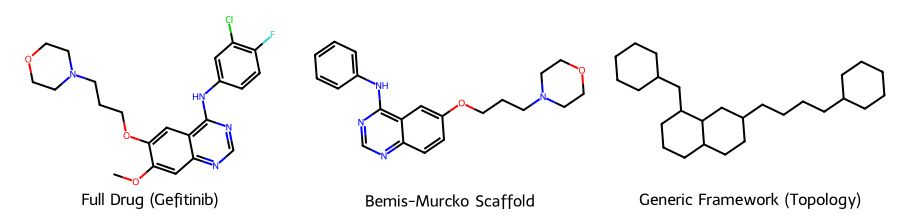

In [2]:
# Example: Gefitinib (Iressa)
gefitinib_smi = "COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN4CCOCC4"
gefitinib = Chem.MolFromSmiles(gefitinib_smi)

# 1. Extract standard Murcko scaffold
scaffold = MurckoScaffold.GetScaffoldForMol(gefitinib)

# 2. Extract generic framework (carbon skeleton)
generic_scaffold = MurckoScaffold.MakeScaffoldGeneric(scaffold)

print("Original SMILES:        ", gefitinib_smi)
print("Murcko Scaffold SMILES: ", Chem.MolToSmiles(scaffold))
print("Generic Framework:      ", Chem.MolToSmiles(generic_scaffold))

Draw.MolsToGridImage(
    [gefitinib, scaffold, generic_scaffold],
    legends=["Full Drug (Gefitinib)", "Bemis-Murcko Scaffold", "Generic Framework (Topology)"],
    molsPerRow=3,
    subImgSize=(300, 220)
)

## 2. Library-Scale Scaffold Frequency Analysis
In drug discovery campaigns, we want to know:
* What are the most common privileged scaffolds?
* Is our library structurally diverse or dominated by a single chemical family?

In [3]:
# Load EGFR dataset
candidate_paths = [
    "datasets/EGFR_compounds.csv",
    "../datasets/EGFR_compounds.csv",
    "../../datasets/EGFR_compounds.csv",
    os.path.expanduser("~/Projects/AI-Engineer-for-Life-Sciences-Libraries/Cheminformatics/RDKit/datasets/EGFR_compounds.csv")
]
csv_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if csv_path:
    df_egfr = pd.read_csv(csv_path).head(500)
    scaffold_counts = {}
    
    for smi in df_egfr["smiles"]:
        m = Chem.MolFromSmiles(smi)
        if m:
            scaff = MurckoScaffold.GetScaffoldForMol(m)
            scaff_smi = Chem.MolToSmiles(scaff)
            scaffold_counts[scaff_smi] = scaffold_counts.get(scaff_smi, 0) + 1
            
    df_scaffolds = pd.DataFrame(list(scaffold_counts.items()), columns=["Scaffold_SMILES", "Frequency"])
    df_scaffolds = df_scaffolds.sort_values(by="Frequency", ascending=False).reset_index(drop=True)
    
    print(f"Total Compounds Processed: {len(df_egfr)}")
    print(f"Total Unique Scaffolds:    {len(df_scaffolds)}")
    print(f"Scaffold-to-Compound Ratio: {len(df_scaffolds)/len(df_egfr):.3f}")
    display(df_scaffolds.head(5))

Total Compounds Processed: 500
Total Unique Scaffolds:    212
Scaffold-to-Compound Ratio: 0.424


,Scaffold_SMILES,Frequency
0,c1ccc(Nc2ncnc3ccccc23)cc1,82
1,c1ccc(Nc2ncnc3cnccc23)cc1,30
2,c1ccc(Nc2ncnc3ccc(OC4CCNCC4)cc23)cc1,15
3,c1ccc(CNc2ncnc3sc(-c4ccccc4)cc23)cc1,15
4,c1ccc(Nc2ncnc3ccncc23)cc1,14


## 3. Visualizing the Top Privileged Scaffolds
Let's render the top 4 most common structural scaffolds across our compound library.

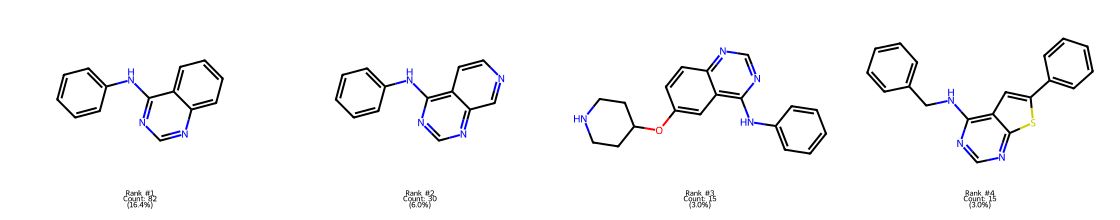

In [4]:
top_scaff_mols = [Chem.MolFromSmiles(s) for s in df_scaffolds["Scaffold_SMILES"].head(4)]
top_scaff_legends = [
    f"Rank #{i+1}\nCount: {row['Frequency']}\n({row['Frequency']/len(df_egfr):.1%})"
    for i, row in df_scaffolds.head(4).iterrows()
]

Draw.MolsToGridImage(top_scaff_mols, legends=top_scaff_legends, molsPerRow=4, subImgSize=(280, 220))

## 4. Cumulative Scaffold Diversity Curve
A diverse chemical library has a gradual cumulative curve, whereas a focused/biased library plateaus rapidly.

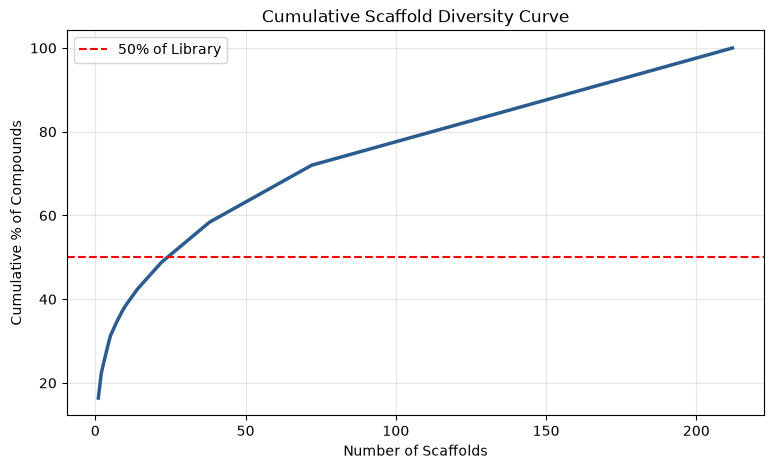

In [5]:
df_scaffolds["Cumulative_Percent"] = df_scaffolds["Frequency"].cumsum() / df_scaffolds["Frequency"].sum() * 100

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(df_scaffolds) + 1), df_scaffolds["Cumulative_Percent"], color="#2b5c8f", linewidth=2.5)
plt.axhline(50, color="red", linestyle="--", label="50% of Library")
plt.xlabel("Number of Scaffolds")
plt.ylabel("Cumulative % of Compounds")
plt.title("Cumulative Scaffold Diversity Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Scaffold Hopping & Matched Molecular Pairs (MMP)
* **Scaffold Hopping:** Replacing the core central scaffold with a completely different ring system while maintaining key 3D pharmacophore interaction vectors.
* **Matched Molecular Pairs (MMP):** Two molecules that differ by only a single well-defined chemical transformation (e.g. $-H \to -Cl$ or $-OCH_3 \to -CF_3$).
* **Activity Cliffs:** When an MMP shows an enormous change in potency ($>100\times$), revealing critical protein binding pockets!

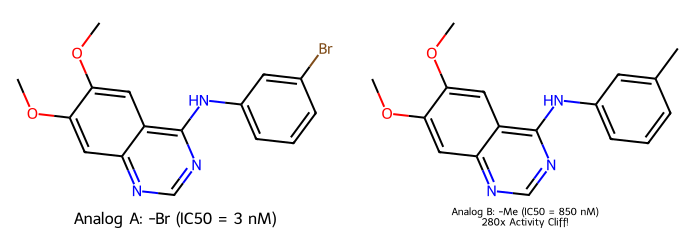

In [6]:
# Example of Matched Molecular Pair (Activity Cliff demonstration)
pair_1 = Chem.MolFromSmiles("COc1cc2ncnc(Nc3cccc(c3)Br)c2cc1OC") # 4-anilinoquinazoline with Br: IC50 = 3 nM
pair_2 = Chem.MolFromSmiles("COc1cc2ncnc(Nc3cccc(c3)C)c2cc1OC")  # Same scaffold with Methyl: IC50 = 850 nM

Draw.MolsToGridImage(
    [pair_1, pair_2],
    legends=["Analog A: -Br (IC50 = 3 nM)", "Analog B: -Me (IC50 = 850 nM)\n280x Activity Cliff!"],
    molsPerRow=2,
    subImgSize=(350, 240)
)

## 6. 🎯 Video Hands-On Challenge & Solution
### Problem:
Take 3 blockbuster cancer drugs:
* **Imatinib**
* **Sorafenib**
* **Erlotinib**
1. Extract their Bemis-Murcko scaffolds.
2. Extract their generic frameworks.
3. Compare their scaffold heavy atom counts and ring counts in a summary table.

=== 🔬 SCAFFOLD DECOMPOSITION SUMMARY ===


,Drug,Full_Atoms,Scaffold_Atoms,Scaffold_Rings
0,Imatinib,37,35,5
1,Sorafenib,32,23,3
2,Erlotinib,29,17,3


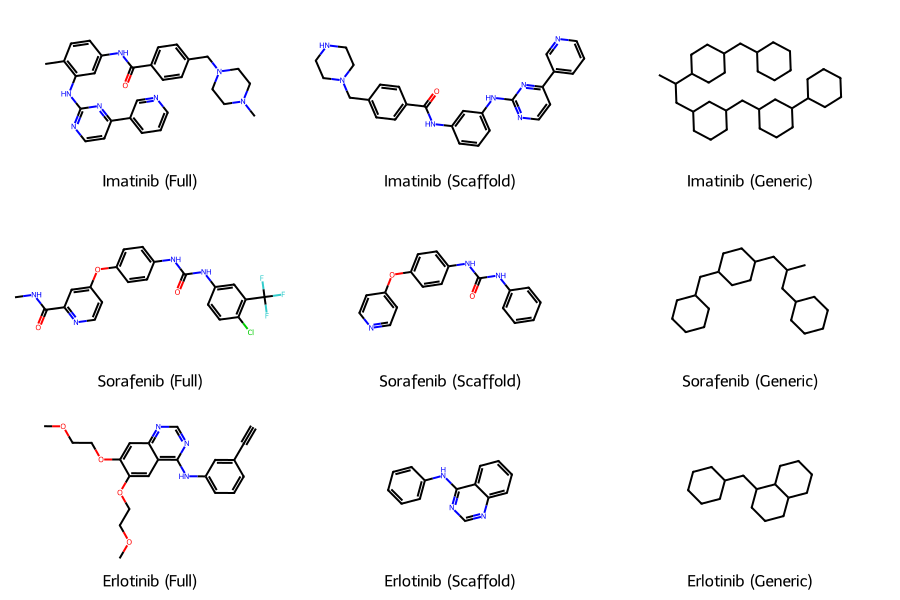

In [7]:
test_drugs = {
    "Imatinib": "Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C",
    "Sorafenib": "CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)c3)cc2)ccn1",
    "Erlotinib": "C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1"
}

scaff_results = []
draw_mols = []
draw_legends = []

for name, smi in test_drugs.items():
    mol = Chem.MolFromSmiles(smi)
    scaff = MurckoScaffold.GetScaffoldForMol(mol)
    generic = MurckoScaffold.MakeScaffoldGeneric(scaff)
    
    scaff_results.append({
        "Drug": name,
        "Full_Atoms": mol.GetNumAtoms(),
        "Scaffold_Atoms": scaff.GetNumAtoms(),
        "Scaffold_Rings": Chem.rdMolDescriptors.CalcNumRings(scaff),
        "Scaffold_SMILES": Chem.MolToSmiles(scaff)
    })
    
    draw_mols.extend([mol, scaff, generic])
    draw_legends.extend([f"{name} (Full)", f"{name} (Scaffold)", f"{name} (Generic)"])

df_res = pd.DataFrame(scaff_results)
print("=== 🔬 SCAFFOLD DECOMPOSITION SUMMARY ===")
display(df_res[["Drug", "Full_Atoms", "Scaffold_Atoms", "Scaffold_Rings"]])

Draw.MolsToGridImage(draw_mols, legends=draw_legends, molsPerRow=3, subImgSize=(300, 200))

## 7. Summary & Key Takeaways
* **Bemis-Murcko Scaffolds** filter out decorative substituents to reveal the core chemical skeleton.
* **Generic Scaffolds** enable topology-level scaffold hopping across different heteroatom systems.
* Scaffold analysis is essential for **Scaffold-based Machine Learning Splits** (Video 15) to prevent artificial data leakage!

**Next Up in Video 13:** **Chemical Reactions & BRICS-Based Molecular Design** — virtual reaction enumeration and fragment-based drug design!